# Procesamiento de Lenguaje Natural: extracción de palabras y frases clave


**Pablo Martínez Olmos, Angel Navia Vázquez**

  * 1.1 (January 2026) Revised and updated version


Departamento de Teoría de la Señal y Comunicaciones

**Universidad Carlos III de Madrid**

<img src='http://www.tsc.uc3m.es/~navia/figures/logo_uc3m_foot.jpg' width=400 />

In [7]:
# Ejecutamos este código para preparar el contexto.
%matplotlib inline
# Figures plotted inside the notebook
%config InlineBackend.figure_format = 'svg'
# High quality figures
import matplotlib.pyplot as plt

In [8]:
# Estas librerías pueden dar problemas de dependencias, conviene instalarlas conjuntamente, para que pip resuelva correctamente las dependencias
!pip install --upgrade numpy pandas scipy gensim spacy nltk rake-nltk

In [9]:
import numpy as np
import scipy
import pandas as pd
import spacy
import gensim
import nltk
import rake_nltk

print(f"NumPy version: {np.__version__}")
print(f"Scipy version: {scipy.__version__}")
print(f"Pandas version: {pd.__version__}")
print(f"Spacy version: {spacy.__version__}")
print(f"Gensim version: {gensim.__version__}")
print(f"NLTK version: {nltk.__version__}")

# 2025:
# NumPy version: 1.26.4
# Scipy version: 1.13.1
# Pandas version: 2.2.3
# Spacy version: 3.8.4
# Gensim version: 4.3.3
# NLTK version: 3.9.1

# 2026:
# NumPy version: 2.4.2
# Scipy version: 1.17.0
# Pandas version: 3.0.0
# Spacy version: 3.8.11
# Gensim version: 4.4.0
# NLTK version: 3.9.2
# RAKE-NLTK version: 1.0.6

NumPy version: 2.4.2
Scipy version: 1.17.0
Pandas version: 3.0.1
Spacy version: 3.8.11
Gensim version: 4.4.0
NLTK version: 3.9.2


En esta sesión presentaremos algunas técnicas sencillas para obtener **frases clave y palabras clave de un documento**. Presentaremos técnicas simples pero potentes para extraer información importante de documentos de texto no estructurados. Éstas pueden utilizarse a efectos meramente de interpretabilidad, pero también como características (features) avanzadas combinables con algún método de aprendizaje.


Utilizaremos el siguiente texto, tomado directamente de [wikipedia](https://en.wikipedia.org/wiki/Gears_of_War_(video_game)).

In [10]:
document = """
Gears of War is a 2006 third-person shooter video game, the first installment of the Gears of War series. It was developed by Epic Games and published by Microsoft Game Studios, initially as an exclusive title for the Xbox 360 in November 2006, before a Microsoft Windows version of the game, developed in conjunction with People Can Fly, was released in 2007. The game's main story, which can be played in single or co-operative play, focuses on a squad of troops who assist in completing a desperate, last-ditch attempt to end a war against a genocidal subterranean enemy, the Locust, and save the remaining human inhabitants of their planet Sera. The game's multiplayer mode allows up to eight players to control characters from one of the two factions in a variety of online game modes. Gameplay features players using cover and strategic fire in order to win battles.
The game was a commercial success, selling over three million copies within ten weeks of its launch. It became the fastest selling video game of 2006, the second-most played game over Xbox Live during 2007, and the 6th best selling Xbox 360 game. Considered one of the seventh generation of video gaming's most significant titles, the game received universal acclaim for its gameplay and detailed visuals, with it winning over 30 "Game of the Year" awards in 2006.
A remastered version, Gears of War: Ultimate Edition, was developed primarily by The Coalition, and brought about a number of improvements, including updates to the gameplay from later titles and enhanced graphics. Ultimate Edition was released for the Xbox One in August 2015, and for Microsoft Windows in March 2016.
Gears of War's success led to the development of a franchise, including four sequels (Gears of War 2 in 2008, Gears of War 3 in 2011, Gears of War 4 in 2016, and Gears 5 in 2019) and two prequels, Gears of War: Judgment, which was released in 2013 and Gears Tactics which was released in 2020. In addition, it has also spawned adaptations for books and comics, and a film based on the series is currently in development.
Gears of War is a third-person shooter that places emphasis on using cover to avoid taking damage while moving towards enemy forces. The game uses a number of weapons, but predominately featured is the Lancer Assault Rifle, which has a mounted chainsaw bayonet that can deal melee damage at close range. Playable characters can carry two primary weapons, grenades, and a smaller, secondary weapon such as the Snub Pistol. Weapons are reloaded with a tap of the RB button, and a second tap within a given time (active reload) rewards the player with a damage bonus. However, failing to perform the "Active Reload" correctly will cause the gun to become momentarily jammed while the player's character fixes it. When the player takes damage, the "Crimson Omen", a red cog representing the player's health gauge, will fade into the screen, becoming more defined with larger amounts of damage. The player can seek cover to recover their health, but if they take too much damage, they will become incapacitated. Once this occurs, a skull will fill the center void of the omen. The player can then be revived by a teammate, executed by an enemy, or remain incapacitated until they "bleed out", dying from blood loss.
The game features a five-act campaign that can be played alone or cooperatively with another player. The campaign focuses on COG Army soldiers Marcus Fenix and Dominic Santiago and their efforts in the Delta Squad to wipe out the Locust forces on their planet Sera. The player is joined by AI teammates that will help fight the Locust. Certain sections of the campaign feature two paths that can be taken as selected by the first player. If there is a second player, their character will automatically take the other. The campaign can be played at three difficulty settings in the first game. From easiest to hardest, these are "Casual", "Hardcore" and "Insane". The "Insane" difficulty is unlocked once the game is beaten on either the "Casual" or "Hardcore" difficulty.
Multiplayer Gears of War features up to four-on-four competitive gameplay, with teams representing the Gears or the Locust. Players must execute downed foes, otherwise these will revive after a time. In Assassination matches, the team's leader is the only one that can track the other team's leader and pick up new weapons, after which teammates can pick them up, with the goal to eliminate the foe's leader. An Xbox 360 patch added the "Annex" mode, which is similar to King of the Hill, in which players must try to control a shifting control point for a certain amount of time to win.The PC version of Gears introduced "King of the Hill", a mode not present in the Xbox 360 version, which uses a fixed control point but varies the conditions on which it is controlled.
Gears of War takes place on the planet Sera. A liquid called Imulsion became a highly valued power source after a scientist discovered how to use it, and the economic shockwave led to several wars between nations. The Coalition of Ordered Governments (COG) originally existed only as an obscure world-government philosophy, but it evolved into a legitimate, though minor, political party during the 79-year-long Pendulum Wars. The soldiers of the COG are called "Gears". After "Emergence Day" (E-Day), when the Locust began their attack on humanity, the COG were the ones who took the necessary steps to ensure the survival of human civilization, instituting martial law and taking charge of the effort against the Locust. Fourteen years later, the COG is the only human government left on Sera. One year after E-Day, after losing battle after battle against the Locust, the COG made the greatest sacrifice using the Hammer of Dawn on human cities, giving the citizens of Sera three days to evacuate to the Jacinto Plateau, the only place Locust could not dig through, before going through with the attack.
The game primarily focuses on Marcus Fenix, the main character, and Delta Squad, consisting of Dominic "Dom" Santiago, Augustus Cole and Damon Baird. Side characters, such as Private Anthony Carmine, and Lieutenant Minh Young Kim, Lieutenant Anya Stroud, and an elderly Stranded man known as Chaps, also aid Delta Squad throughout the narrative. Players take control of Fenix in the campaign; while in co-op mode, the second player controls Santiago. All four Delta squad members are available for play during multiplayer games, along with Carmine, Kim, and Colonel Victor Hoffman, in addition to the various Locust characters.
The first concept for the game was conceived around the years 2000 and 2001 as Unreal Warfare, which was much closer to the multiplayer-driven Unreal series than the game that would eventually become Gears of War. The original concept for the game featured character classes and mechs, being played in a closed arena against other players or bots. The game was put on standby as Epic focused on the Unreal Tournament series, and when the team went back to it, the industry had shifted towards single-player games and the aim of the game was changed.
Cliff Bleszinski served as lead designer on Gears of War.According to Rod Fergusson, the game was at one point intended to be a horror game influenced by Band of Brothers, Resident Evil 4 and Kill Switch. A romance subplot was considered for the game but was eventually dropped. In an interview with Cliff Bleszinski, lead developer for Epic Games, he cites three games that were the primary influences in the game's design, including the pacing and over-the-shoulder third-person perspective from Resident Evil 4 and the tactical-cover system from Kill Switch; Bleszinski also cited Bionic Commando's influence on the cover system, equating the actions of moving from cover to cover as similar to the action of swinging from platform to platform in the latter game. These design choices reflect themselves in the gameplay, as Gears of War focuses mainly on squad team-based and cover-dependent tactics with limited weapons rather than brute force. Bleszinski also cited the influence of The Legend of Zelda, including its storytelling and world-building elements, acquiring and mastering of tools, and underground environments. The game's title itself is a homage to Metal Gear, an early formative influence on Bleszinski. The total cost of development was $10 million, according to Epic's Mark Rein, and 20 to 30 people were involved with the development at any time. However, these figures do not include the proprietary Unreal Engine 3.
Gears of War was first shown as an unnamed exclusive for the Xbox 360 in a behind-closed-doors presentation by Epic Games at the 2005 Game Developers Conference. The demo was presented as a technology showcase for Unreal Engine 3 that would run on the Xenon processor at the center of the new Xbox. It showcased a group of human soldiers patrolling a city at night that fell under ambush. The demo was noted for its overall realism, suspense, and visual clarity, helping to reinforce the argument advanced by Epic Games' founder Tim Sweeney for Microsoft to double the memory in the Xbox 360 from the planned 256 MB to 512 MB. This decision that would ultimately cost Microsoft tens of millions of dollars and restrict the number of Xbox 360 consoles available at launch, but allowed Gears of War and many other Xbox 360 games to run at 720p resolution.
Gears of War lead designer Cliff Bleszinski said he hoped for the game to expand into graphic novels and eventually film. On November 21, 2006, Microsoft Corporate VP of Global Marketing and Interactive Entertainment Business Jeff Bell stated Gears of War is the first in a trilogy, through sequences on E-Day and the battle of Jacinto Plateau, as well as information on Adam Fenix and his research.[20] Epic Games Vice President Mark Rein posted a message on the official Gears of War Internet forums, stating "It's not over until it is not fun anymore", and, in his view, Gears of War may become the next Halo series in terms of popularity.
The ending to Gears of War heavily suggested a sequel, and at the 2007 Game Developers Conference, Bleszinkski confirmed that Epic Games did "intend to do a sequel" to Gears of War. The game's sequel, Gears of War 2 was officially confirmed on February 20, 2008, and was released at midnight on November 7, 2008. On January 27, 2014 Microsoft announced that they have acquired all rights to the franchise from Epic Games and that Rod Fergusson had rejoined Microsoft Studios to lead development on future Gears of War games.
Upon its release, Gears of War received universal acclaim from critics, maintaining an average review score of 93.97% at GameRankings and 94/100 at Metacritic. It was the second highest rated game of 2006 on both sites. Most reviewers praised the game for its concept visuals, presentation and sound. IGN's review of the game called it "the most gorgeous looking game on the Xbox 360" and that "the sound design is worthy of awards."
While the game received high praise, reviewers did point out that Gears of War did not offer anything significantly new in its core gameplay. Eurogamer's review of the game states: "let's not pretend that we're wallowing in the future of entertainment. What we have here is an extremely competent action game that's as polished and refined as it could be, and is therefore very enjoyable. But if Epic had applied the same widescreen scope and ambition to the gameplay as it did to the engine we'd be much more excited than we are." The game's story was noted for not being very deep, as GameSpot's review states "The lack of exposition feels like a missed opportunity to make the characters and the setting even more compelling."
The PC release of the game received similar praise as the 360 version, with reviewers noting various differences between the two versions. IGN commented that "The mouse and keyboard allow for more precise control, and the graphics have been improved as well;" however, 1UP stated that "the control scheme's a very central obstacle" to the game.[63] GameSpot noted that the additional chapter felt out of place as "it changes things up a bit in ways that betray the difficulty progression of the game.” Hyper's Cam Shea commends the game for its "visual, solid gameplay, killer multiplayer and reload mechanics". However, he criticised it for "potential frustration, pointless squad commands and chainsaw mechanics"
The Lancer weapon was later featured in an Electronic Gaming Monthly article that discusses its practicality and historical precedents. Keirsey criticized this weapon by noting that in real life, "chainsaws are heavy." He noted that the closest historical precedents are "medieval bludgeoning weapons".
"""


Imprimamos el documento de ejemplo para comprobar que lo hemos definido correctamente y se trata de una variable tipo string:

In [11]:
print(type(document))
print(document)

<class 'str'>

Gears of War is a 2006 third-person shooter video game, the first installment of the Gears of War series. It was developed by Epic Games and published by Microsoft Game Studios, initially as an exclusive title for the Xbox 360 in November 2006, before a Microsoft Windows version of the game, developed in conjunction with People Can Fly, was released in 2007. The game's main story, which can be played in single or co-operative play, focuses on a squad of troops who assist in completing a desperate, last-ditch attempt to end a war against a genocidal subterranean enemy, the Locust, and save the remaining human inhabitants of their planet Sera. The game's multiplayer mode allows up to eight players to control characters from one of the two factions in a variety of online game modes. Gameplay features players using cover and strategic fire in order to win battles.
The game was a commercial success, selling over three million copies within ten weeks of its launch. It became t

# 1 - Preprocesado lingüístico y segmentación en frases

A continuación vamos a preprocesar el texto usando la librería Spacy, tal y como hemos visto en la clase anterior.

In [12]:
# Usamos el modelo "small"
nlp_spacy = spacy.load("en_core_web_sm")

doc_spacy = nlp_spacy(document)
print(type(doc_spacy))

<class 'spacy.tokens.doc.Doc'>


El primer paso será **dividir el documento en frases individuales**. Para ello, recordemos que Spacy nos proporciona ``doc.sents`` , que es un **generador** de frases individuales (iterable).

En Python, un **generador** es una **función que devuelve un iterador**. Los generadores son útiles cuando queremos producir una gran secuencia de valores, pero **no queremos almacenarlos todos en la memoria a la vez**.

Para **ampliar el conocimiento sobre generadores e iteradores**, podeis visitar este [**tutorial**](https://www.datacamp.com/tutorial/python-iterators-generators-tutorial).








En Python, un **iterable** es un objeto sobre el que se puede iterar, lo que significa que se puede recorrer o acceder a un elemento a la vez. Los iterables son un concepto fundamental en Python y se utilizan ampliamente en diversas tareas de programación.

Se pueden utilizar por ejemplo en bucles ``for`` o ``list comprehension`` y se pueden **convertir** a otras estructuras de datos, como listas, tuplas o conjuntos, utilizando las funciones ``list()``, ``tuple()`` o ``set()``, respectivamente.

El uso de iterables en Python ofrece varias **ventajas**:

- **Eficiencia de la memoria**: los iterables pueden manejar grandes conjuntos de datos sin consumir memoria excesiva, ya que solo cargan los datos según sea necesario.

- **Evaluación diferida ("lazy evaluation")**: los iterables se pueden evaluar de forma diferida, lo que significa que los elementos se generan y devuelven solo cuando son necesarios, en lugar de todos a la vez.

- **Modularidad**: los iterables se pueden componer y combinar fácilmente, lo que permite un código más modular y reutilizable.





Podemos recorrer cada una de las frases usando la sintaxis habitual ("`for frase in doc.sents`"), tanto dentro de un bucle como en una "list comprehension".

Para algunos procesados podemos directamente **iterar**, pero en otras ocasiones nos puede interesar **convertir** su formato, por ejemplo a una **lista de frases**.

**NOTA:** Cuidado si los conjuntos de datos son muy grandes, procesar/almacenar simultaneamente todos los datos puede ser muy costoso, en cuyo caso es mucho más eficiente usar el iterador. **Para conjuntos de datos pequeños, los enfoques basados ​​en iteradores y listas tienen un rendimiento similar. Para conjuntos de datos más grandes, los iteradores ahorran tiempo y memoria/almacenamiento.**


Este sería el enfoque procesando el documento para convertirlo en lista de frases:

In [13]:
print(type(doc_spacy.sents))

# Convertimos el iterable en una lista:
frases_list = list(doc_spacy.sents)

print('Obtenemos una lista de strings, de longitud {} (hay {} frases en el documento).'.format(len(frases_list), len(frases_list)))
print(type(frases_list))
print(type(frases_list[0]))

print('\nTenemos acceso a cada frase individual, por ejemplo, ésta sería la frase número 5:\n')
print(frases_list[5])


<class '_cython_3_2_1.generator'>
Obtenemos una lista de strings, de longitud 82 (hay 82 frases en el documento).
<class 'list'>
<class 'spacy.tokens.span.Span'>

Tenemos acceso a cada frase individual, por ejemplo, ésta sería la frase número 5:

The game was a commercial success, selling over three million copies within ten weeks of its launch.


Pero en el caso del **generador, no podemos acceder directamente a un elemento específico o subconjunto** de los elementos, pues se produce un **error** al no ser una estructura indexada:

In [15]:
# Obtenemos un ERROR si intentamos acceder a una posición concreta del generador
print(doc_spacy.sents[4])

TypeError: '_cython_3_2_1.generator' object is not subscriptable

In [16]:
# Obtenemos un ERROR si intentamos acceder a una parte concreta del generador
for sentence in doc_spacy.sents[8:10]:
    print(sentence.text)
    print('-' * 100)

TypeError: '_cython_3_2_1.generator' object is not subscriptable

Para acceder a algunos de los elementos de un **generador (iterable no indexado)** podemos usar los métodos ``next`` y `islice` de la librería `itertools`.

In [17]:
from itertools import islice

print('-' * 50)
print("Accediendo a la frase número 5:")
print('-' * 50)
print(type(next(islice(doc_spacy.sents, 5, 6))))
print(next(islice(doc_spacy.sents, 5, 6)).text)
print("\n")

print('-' * 50)
print("Resultados usando lista de strings:")
print('-' * 50)
print(frases_list[5])
print("\n")


print('-' * 50)
print("Extrayendo un subconjunto de datos usando islice:")
print('-' * 50)
for doc in islice(doc_spacy.sents, 8, 10):
    print(doc.text)
print("\n")

print('-' * 50)
print("Resultados usando lista de strings:")
print('-' * 50)
for i in range(8, 10):
  print(frases_list[i])



--------------------------------------------------
Accediendo a la frase número 5:
--------------------------------------------------
<class 'spacy.tokens.span.Span'>
The game was a commercial success, selling over three million copies within ten weeks of its launch.


--------------------------------------------------
Resultados usando lista de strings:
--------------------------------------------------
The game was a commercial success, selling over three million copies within ten weeks of its launch.


--------------------------------------------------
Extrayendo un subconjunto de datos usando islice:
--------------------------------------------------
A remastered version, Gears of War: Ultimate Edition, was developed primarily by The Coalition, and brought about a number of improvements, including updates to the gameplay from later titles and enhanced graphics.
Ultimate Edition was released for the Xbox One in August 2015, and for Microsoft Windows in March 2016.



---------------

A continuación, normalizamos el documento. Dividiremos primero el **documento en frases** iterando sobre `doc.sents` y luego **normalizamos** cada una de ellas, convirtiéndolas en una **lista de tokens**. Revise la sintaxis de la siguiente "list comprehension":

In [18]:
# Normalizamos el documento dividido en frases, usando Spacy
norm_sent_tokens = [[w.lemma_.lower() for w in frase if not w.is_stop
                  and not w.is_punct and (w.is_alpha or w.is_digit)] for frase in doc_spacy.sents]

El formato resultante debe ser análogo al resultado de procesar un corpus de documentos: lista de listas de strings (tokens).

**NOTA**: Fijémonos que en esta tarea, el texto completo es el corpus, y cada frase ejerce el papel de documento del corpus.  

In [19]:
print("El documento contiene {} frases y es una lista de listas de strings:".format(len(norm_sent_tokens)))
print(type(norm_sent_tokens))
print(type(norm_sent_tokens[0]))
print(type(norm_sent_tokens[0][0]))

print("\nEstos son los tokens de la primera frase:")
print(norm_sent_tokens[0])
print("\nEstos son los tokens de la frase 8:")
print(norm_sent_tokens[8])



El documento contiene 82 frases y es una lista de listas de strings:
<class 'list'>
<class 'list'>
<class 'str'>

Estos son los tokens de la primera frase:
['gears', 'war', '2006', 'person', 'shooter', 'video', 'game', 'installment', 'gears', 'war', 'series']

Estos son los tokens de la frase 8:
['remastered', 'version', 'gears', 'war', 'ultimate', 'edition', 'develop', 'primarily', 'coalition', 'bring', 'number', 'improvement', 'include', 'update', 'gameplay', 'later', 'title', 'enhanced', 'graphic']


# 2 - Codificación TF-IDF

Como paso previo al método **Latent Semantic Analysis** (que introduciremos en la siguiente sección), calcularemos la **matriz TF-IDF** del documento, procesando cada frase por separado. En este caso, las frases juegan el papel de documentos en un corpus. Usaremos la librería **Gensim para generar el vocabulario y obtener la parametrización TFIDF**, como hemos visto en el tema anterior.  

In [20]:
import gensim

# Let us extract the vocabulary from the corpus:
Vocab = gensim.corpora.Dictionary(norm_sent_tokens)

n_tokens = len(Vocab)

print('The vocabulary contains', n_tokens, 'terms')
print('First terms in the vocabulary:')
for n in range(10):
    print(str(n), ':', Vocab[n])

The vocabulary contains 613 terms
First terms in the vocabulary:
0 : 2006
1 : game
2 : gears
3 : installment
4 : person
5 : series
6 : shooter
7 : video
8 : war
9 : 2007


Analicemos la **frecuencia de aparición de cada palabra** del vocabulario en todo el corpus (un texto compuesto por frases, en nuestro caso) usando los diccionarios **"Vocab.cfs" (número de veces que una palabra aparece en total en el corpus) y "Vocab.dfs" (número de documentos en los que aparece dicha palabra)**, y representemos las gráficas correspondientes.

In [21]:
print(type(Vocab.cfs))

keys = list(Vocab.cfs.keys())

print("\nAlgunos de los elementos del diccionario cfs:\n")
for k in range(5):
  print('La palabra "{}" aparece {} veces en el corpus.'.format(Vocab[keys[k]], Vocab.cfs[keys[k]]))


<class 'dict'>

Algunos de los elementos del diccionario cfs:

La palabra "gears" aparece 24 veces en el corpus.
La palabra "war" aparece 28 veces en el corpus.
La palabra "2006" aparece 6 veces en el corpus.
La palabra "person" aparece 3 veces en el corpus.
La palabra "shooter" aparece 2 veces en el corpus.


Representemos dichas frecuencias en un gráfico, ordenando de mayor a menor.

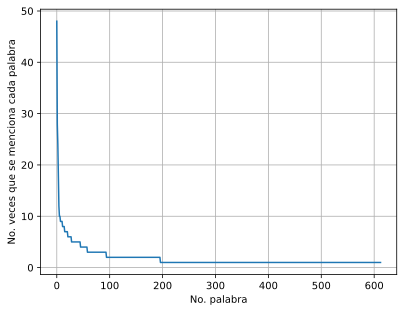

Las dos palabras más mencionadas son "game" (48 veces) y "war" (28 veces).


In [22]:
sorted_cfs_items = sorted(Vocab.cfs.items(), key=lambda item: item[1], reverse=True)
sorted_cfs_keys = [item[0] for item in sorted_cfs_items]
sorted_cfs_values = [item[1] for item in sorted_cfs_items]

plt.plot(sorted_cfs_values)
plt.grid()
plt.xlabel('No. palabra')
plt.ylabel('No. veces que se menciona cada palabra')
plt.show()

print('Las dos palabras más mencionadas son "{}" ({} veces) y "{}" ({} veces).'.format(Vocab[sorted_cfs_keys[0]], sorted_cfs_values[0], Vocab[sorted_cfs_keys[1]], sorted_cfs_values[1]))

Veamos ahora la frecuencia de aparición en documentos, y representemos también un gráfico ordenado de mayor a menor:

In [23]:
print(type(Vocab.dfs))

keys = list(Vocab.dfs.keys())

print("\nAlgunos de los elementos del diccionario cfs:\n")
for k in range(5):
  print('La palabra "{}" aparece en {} frases.'.format(Vocab[keys[k]], Vocab.dfs[keys[k]]))

<class 'dict'>

Algunos de los elementos del diccionario cfs:

La palabra "gears" aparece en 16 frases.
La palabra "war" aparece en 20 frases.
La palabra "2006" aparece en 6 frases.
La palabra "person" aparece en 3 frases.
La palabra "shooter" aparece en 2 frases.


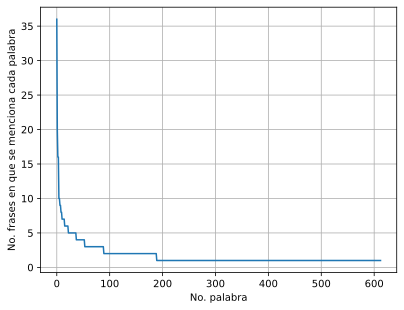

Las dos palabras que aparecen en más frases son "game" (36 frases) y "war" (20 frases).


In [24]:
sorted_dfs_items = sorted(Vocab.dfs.items(), key=lambda item: item[1], reverse=True)
sorted_dfs_keys = [item[0] for item in sorted_dfs_items]
sorted_dfs_values = [item[1] for item in sorted_dfs_items]

plt.plot(sorted_dfs_values)
plt.grid()
plt.xlabel('No. palabra')
plt.ylabel('No. frases en que se menciona cada palabra')
plt.show()

print('Las dos palabras que aparecen en más frases son "{}" ({} frases) y "{}" ({} frases).'.format(Vocab[sorted_dfs_keys[0]], sorted_dfs_values[0], Vocab[sorted_dfs_keys[1]], sorted_dfs_values[1]))

## Ejercicio:

Vamos a **filtrar** todas aquellas palabras que no aparezcan en **al menos dos frases** y las que aparezcan en más del **80% de las frases** utilizando el método **"filter_extremes"** de Gensim.

In [ ]:
no_below = <INSERT CODE HERE> #Minimum number of documents to keep a term in the vocabulary
no_above = <INSERT CODE HERE> #Maximum proportion of documents in which a term can appear to be kept in the vocabulary

Vocab.<INSERT CODE HERE>

n_tokens = <INSERT CODE HERE>

print('The reduced dictionary now contains', n_tokens, 'terms')
print('First terms in the dictionary:')
for n in range(10):
    print(str(n), ':', Vocab[n])

## Solución

In [25]:
no_below = 2 #Minimum number of documents to keep a term in the dictionary
no_above = .8 #Maximum proportion of documents in which a term can appear to be kept in the dictionary

Vocab.filter_extremes(no_below=no_below, no_above=no_above)

n_tokens = len(Vocab)

print('The reduced dictionary now contains', n_tokens, 'terms')
print('First terms in the dictionary:')
for n in range(10):
    print(str(n), ':', Vocab[n])

The reduced dictionary now contains 189 terms
First terms in the dictionary:
0 : 2006
1 : game
2 : gears
3 : person
4 : series
5 : shooter
6 : video
7 : war
8 : 2007
9 : 360


## Ejercicio:

Generamos la parametrización TF-IDF:

In [ ]:
from gensim.models import TfidfModel

# corpus_bow is a list, each element is the bow (sparse count) for every sentence
corpus_bow = <INSERT CODE HERE>

# TFIDF model
model = <INSERT CODE HERE>

# TFIDF parameterization of the corpus (TransformedCorpus gensim object)
corpus_tfidf = <INSERT CODE HERE>


## Solución    

In [26]:
from gensim.models import TfidfModel

# corpus_bow is a list, each element is the bow (sparse count) for every sentence
corpus_bow = [Vocab.doc2bow(doc) for doc in norm_sent_tokens]

# TFIDF model
model = TfidfModel(corpus_bow)

# TFIDF parameterization of the corpus (TransformedCorpus gensim object)
corpus_tfidf = model[corpus_bow]

Convertimos a **representación matricial densa (Numpy array)**, pues la necesitamos para aplicar el análisis matricial (LSA). Recordemos que es necesario indicar explícitamente el número de tokens y de documentos (frases en este caso):

In [27]:
from gensim.matutils import corpus2dense, corpus2csc

n_tokens = len(Vocab)
num_docs = len(corpus_bow)
# Convert BoW representacion to numpy array (dense Nwords x Ndocs)
corpus_bow_dense = corpus2dense(corpus_bow, num_terms=n_tokens, num_docs=num_docs)
# Convert TFIDF representacion to numpy array (dense Nwords x Ndocs)
corpus_tfidf_dense = corpus2dense(corpus_tfidf, num_terms=n_tokens, num_docs=num_docs)

print("Obtenemos una matriz de tipo Numpy Array (densa):")
print(type(corpus_tfidf_dense))

print("\nEl tamaño de la matriz es No. palabras en el vocabulario x No. documentos:")
print(corpus_tfidf_dense.shape)

print("\nVemos que muchas de las posiciones están a valor 0:")
print(corpus_tfidf_dense[0:5, 0:5])

Obtenemos una matriz de tipo Numpy Array (densa):
<class 'numpy.ndarray'>

El tamaño de la matriz es No. palabras en el vocabulario x No. documentos:
(189, 82)

Vemos que muchas de las posiciones están a valor 0:
[[0.31330192 0.17875959 0.         0.         0.        ]
 [0.09862875 0.11254854 0.06581469 0.19223909 0.        ]
 [0.39157483 0.         0.         0.         0.        ]
 [0.39634883 0.         0.         0.         0.        ]
 [0.3351461  0.         0.         0.         0.        ]]


# 3 - Resumen de texto utilizando *Latent Semantic Analysis* (LSA)

[Este método](http://www.kiv.zcu.cz/~jstein/publikace/isim2004.pdf) utiliza la descomposición en valores singulares (SVD) de la matriz TF-IDF $\mathbf{A}$ calculada anteriormente para hacer una **selección de las frases principales**. $\mathbf{A}$ tiene dimensiones $m\times n$, donde $m$ corresponde en nuestro caso al  tamaño del diccionario (`len(Vocab)`) y $n$ al número de documentos (frases en nuestro caso). Asumiendo $m>n$, la descomposición SVD de $\mathbf{A}$ es de la forma
$$\mathbf{A}=\mathbf{U}\mathbf{\Sigma}\mathbf{V}^T$$
donde

- $\mathbf{U}$ es una matriz $m\times m$ ortonormal.
- $\mathbf{V}$ es una matriz $n\times n$ ortonormal.
- $\mathbf{\Sigma}$ es una matriz $m\times n$ con $n$ valores distintos de zero en la diagonal principal. Estos valores, $\sigma_1,\sigma_2,\ldots,\sigma_n$ son los **valores singulares**. Además, asumimos que están ordenados, de forma que $\sigma_1>\sigma_2,\ldots,\sigma_n$.







La siguiente figura ilustra la descomposición

<img src='http://www.tsc.uc3m.es/~navia/figures/Singular_value_decomposition_visualisation.svg' width=300 />


## 3.1 - Aproximación de rango-$k$ usando SVD

Tras la construcción de la matriz TFIDF de ocurrencia, es conveniente reducir su rango, por varios motivos, ya que la matriz **A** inicial:

- podría ser **demasiado grande** para los recursos informáticos y la versión de rango reducido optimiza recursos asumiendo un error de aproximación, que suele ser bajo.

- puede **contener ruido**, por tanto la versión de bajo rango puede suponer una mejora de prestaciones.

- es **demasiado dispersa** escasa en relación con la matriz término-documento "verdadera". En la versión de bajo rango se combinan algunas dimensiones, de forman que se pueden abordar problemas como el de los sinónimos, por ejemplo.

Si utilizamos únicamente las componentes correspondientes asociadas a los $k$ valores singulares de mayor valor, construiremos una aproximación a la matriz $\mathbf{A}$ de rango $k$:

<img src='http://www.tsc.uc3m.es/~navia/figures/SVDk.png' width=700 />


En este contexto, a la dimensión latente $k$ se le denomina el **número de temas (topics) de la descomposición**.

Así, la matriz **U** es aproximada por ``k`` columnas, cada una de ellas describiendo un tópico. Por ejemplo, imaginemos que nuestro vocabulario sólo contiene 5 palabras (m=5): "coche", "automóvil", "préstamo", "interés", "crédito", y que los 5 valores de la primera columna de **U** son: [0.3, 0.4, 0, 0, 0]. Esto nos está indicando que el primer "tópico" sería ``0.3 * "coche" + 0.4 * "automóvil"``, asimilable en este caso al concepto "vehículo de motor". Podría haber un segundo tópico relacionado con "economía/banca" (k=2):

- ``topic1 = 0.3 * "coche" + 0.4 * "automóvil"``
- ``topic2 = 0.6 * "préstamo" + 0.2 * "interés" + 0.4 * "crédito" ``

Obviamente, en la práctica no obtendremos resultados tan claros.

Por otro lado, imaginemos que tenemos 3 documentos (n=3), de modo que cada fila de **V** nos indica cómo se expresa cada documento en función de los tópicos:

- ``doc1 = 0.5 * topic1``
- ``doc2 = 0.6 * topic2``
- ``doc3 = 0.3 * topic1 + 0.2 * topic2``

Asumiendo estas representaciones, podríamos decir que el primero de los documentos trata únicamente sobre vehículos, el segundo sobre conceptos bancarios y el tercero sobre cómo adquirir un vehículo pidiendo un préstamo.


Bajo esta aproximación, por tanto, cada elemento de $\mathbf{A}$ se reconstruye (aproximadamente) como el producto escalar de dos vectores

$$a_{i,j} \approx  < \mathbf{u}_i, \mathbf{g}_j>$$

donde $\mathbf{u}_i$ es la fila i-ésima de la matriz **U**, $\mathbf{v}_j$ es la columna i-ésima de **$V^T$**, $\sigma_{1:k}$ son los valores de la diagonal de $\Sigma$ y finalmente $\mathbf{g}_k = \mathbf{\sigma}_{1:k} * \mathbf{v}_j$ es el producto elemento a elemento de ambos vectores.


## 3.2 - Frases más representativas

Utilizando LSA, se entenderán las frases más representativas como aquellas para las cuales la norma del vector $\mathbf{g}_k$ **es mayor**. A los coeficientes $s_j, j=1,\ldots,n$ se les denomina **saliency scores**:

$$s_j \doteq ||\mathbf{g}_k||_2 = \sqrt{\sum_{u=1}^{k}\sigma_u^2 v_{j,u}^2}$$




Vamos a aplicar el método LSA para encontrar las frases más representativas de nuestro texto de ejemplo.


## 3.3 - Cálculo de la SVD usando `Scipy`

In [28]:
# svds calcula la descomposición SVD de una matriz tando densa como sparse
from scipy.sparse.linalg import svds

def low_rank_svd(matrix, singular_count=2):
    U, S, VT = svds(matrix, k=singular_count)
    return U, S, VT

El número de tópicos (k) es un **hiperparámetro que debemos fijar** antes de realizar el análisis. Podemos jugar con distintos valores para ver su efecto. En general, se recomienda un **número relativamente bajo en relación con el número de documentos**, a fin de que se produzca cierta **"compactación de conceptos"**.

En este [artículo](http://www.kiv.zcu.cz/~jstein/publikace/isim2004.pdf), proponen el siguiente heurístico para no tener en cuenta valores singulares asociados a tópicos con poca importancia. En particular, para el cálculo del *saliency score* **pondremos a cero todos aquellos valores singulares cuya magnitud esté por debajo de la mitad del valor del máximo valor singular**.

(189, 82)


Text(0.5, 0, 'No. singular value')

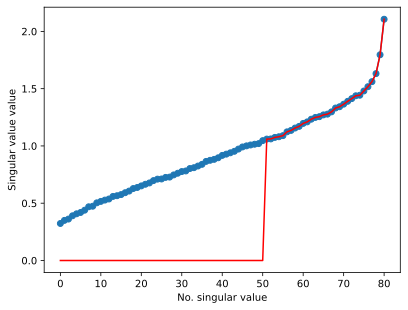

In [29]:
print(corpus_tfidf_dense.shape)

# Veamos todos los valores singulares
U, S, VT = svds(corpus_tfidf_dense, corpus_tfidf_dense.shape[1]-1)

# Aplicando umbral para eliminar los valores singulares más pequeños
sv_threshold = 0.5
min_sigma_value = max(S) * sv_threshold
S_croped = np.copy(S)
S_croped[S_croped < min_sigma_value] = 0

fig = plt.figure()
plt.plot(S,'o-')
plt.plot(S_croped,'r-')
plt.ylabel('Singular value value')
plt.xlabel('No. singular value')


Vemos que la aplicación de este umbral ha anulado algunos valores singulares.

In [30]:
print('Hay {} valores singulares por encima del umbral, se han eliminado {}.'.format(np.sum(S_croped>0), np.sum(S_croped==0)))

Hay 30 valores singulares por encima del umbral, se han eliminado 51.


In [31]:
# Vamos a observar los resultados reteniendo sólo los 3 valores singulares principales (3 tópicos)
num_sentences = 8  # Número de frases a retener más adelante
num_topics = 3 # Número de tópicos

U_term_topic_mat, S, VT_topic_document_mat = low_rank_svd(corpus_tfidf_dense, singular_count=num_topics)
print(U_term_topic_mat.shape, S.shape, VT_topic_document_mat.shape)

(189, 3) (3,) (3, 82)


A continuación calculamos los scores

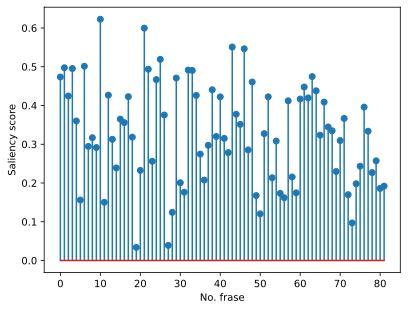

In [32]:
salience_scores = np.linalg.norm(S.reshape([num_topics,1]) * VT_topic_document_mat,axis=0)
plt.stem(salience_scores)
plt.xlabel('No. frase')
plt.ylabel('Saliency score')
plt.show()

In [33]:
# comprobamos sus saliency indices
top_sentence_indices = np.argsort(-salience_scores)

print("Estos son los saliency scores de mayor a menor:")
print(salience_scores[top_sentence_indices])

print('\n' + '-' * 50)

print("Estos son los índices ordenados de mayor a menor valor de saliency score:")
print(top_sentence_indices)

Estos son los saliency scores de mayor a menor:
[0.62256783 0.5996645  0.5508465  0.5463055  0.51908225 0.5013025
 0.497398   0.49546054 0.49367622 0.49145204 0.49043998 0.4746322
 0.4735371  0.4708475  0.4667967  0.46060145 0.4476655  0.44052914
 0.4378775  0.42676374 0.42602208 0.42447907 0.42277923 0.42238554
 0.42223424 0.41962096 0.41673648 0.41209185 0.40889803 0.39581826
 0.37752447 0.37545228 0.3666356  0.36488545 0.3600661  0.35577387
 0.3513427  0.34458062 0.33471516 0.3335868  0.32739633 0.3234675
 0.32000166 0.31834102 0.31678408 0.31507927 0.31279916 0.30949047
 0.3083719  0.2972879  0.29440907 0.29150948 0.28542712 0.27848685
 0.2745926  0.25721455 0.25607777 0.24326766 0.23884578 0.23248242
 0.22960623 0.22681543 0.21548937 0.21358752 0.20758756 0.20057327
 0.19811115 0.19196829 0.18600611 0.17618066 0.174696   0.17319599
 0.16983774 0.16749057 0.16194853 0.15606081 0.15025602 0.12426692
 0.1203955  0.09695853 0.03896531 0.03379523]

-------------------------------------

Finalmente buscamos las 8 **frases con mayor "saliency score"**:

In [34]:
# retenemos sólo los 8 índices principale:
top_8_indices = top_sentence_indices[:num_sentences]

# Ordenamos los índices para coherencia con el orden en el texto.
top_8_indices.sort()
print("Estas son las frases a retener en el resumen:")
print(top_8_indices)

Estas son las frases a retener en el resumen:
[ 1  3  6 10 21 25 43 46]


In [35]:
print('=' * 50)
print('RESUMEN DEL TEXTO USANDO LAS 8 FRASES PRINCIPALES:')
print('=' * 50, "\n")
for l in top_8_indices:
    print(frases_list[l])
    print('-' * 80)

RESUMEN DEL TEXTO USANDO LAS 8 FRASES PRINCIPALES:

It was developed by Epic Games and published by Microsoft Game Studios, initially as an exclusive title for the Xbox 360 in November 2006, before a Microsoft Windows version of the game, developed in conjunction with People Can Fly, was released in 2007.
--------------------------------------------------------------------------------
The game's multiplayer mode allows up to eight players to control characters from one of the two factions in a variety of online game modes.
--------------------------------------------------------------------------------
It became the fastest selling video game of 2006, the second-most played game over Xbox Live during 2007, and the 6th best selling Xbox 360 game.
--------------------------------------------------------------------------------
Gears of War's success led to the development of a franchise, including four sequels (Gears of War 2 in 2008, Gears of War 3 in 2011, Gears of War 4 in 2016, and G

Podemos ver cómo **LSA nos proporciona una selección de frases** que cubre los aspectos principales de la descripción de nuestro juego.

### Ejercicio:

Visualice las 5 frases con **menor** saliency score. ¿Son menos informativas que las seleccionadas en el apartado anterior?

In [ ]:
<INSERT CODE HERE>

### Solution

In [36]:
worst_sentence_indices = top_sentence_indices[::-1]

print('=' * 30)
print('5 FRASES MENOS IMPORTANTES:')
print('=' * 30)
for l in worst_sentence_indices[0:5]:
    print(frases_list[l])
    print('-' * 80)

5 FRASES MENOS IMPORTANTES:
Once this occurs, a skull will fill the center void of the omen.
--------------------------------------------------------------------------------
From easiest to hardest, these are "Casual", "Hardcore" and "Insane".
--------------------------------------------------------------------------------
What we have here is an extremely competent action game that's as polished and refined as it could be, and is therefore very enjoyable.
--------------------------------------------------------------------------------
A romance subplot was considered for the game but was eventually dropped.
--------------------------------------------------------------------------------
The "Insane" difficulty is unlocked once the game is beaten on either the "Casual" or "Hardcore" difficulty.

--------------------------------------------------------------------------------


### Ejercicio:

Explore la matriz de términos e identifique los 20 términos principales de cada tópico. Intente interpretar los resultados, analizando el sentido de cada uno de los tópicos.

In [ ]:
for k in <INSERT CODE HERE>:
  topic_values = <INSERT CODE HERE>
  top_topic_indices = np.argsort(-topic_values)
  topic_tokens = <INSERT CODE HERE>
  print("\nEstos son los 20 términos principales del tópico #{}:".format(i))
  print(topic_tokens)

### Solution

In [37]:
for k in range(3):
  topic_values = U_term_topic_mat[:,k]
  top_topic_indices = np.argsort(-topic_values)
  topic_tokens = [Vocab[i] for i in top_topic_indices[0:20]]
  print("\nEstos son los 20 términos principales del tópico no. {}:".format(k))
  print(topic_tokens)



Estos son los 20 términos principales del tópico no. 0:
['locust', 'take', 'cog', 'sera', 'human', 'day', 'war', 'cover', 'gear', 'planet', 'soldier', 'squad', 'force', 'damage', 'place', 'focus', 'gears', 'bleszinski', 'government', 'year']

Estos son los 20 términos principales del tópico no. 1:
['player', 'character', 'campaign', 'play', 'feature', 'second', 'control', 'weapon', 'damage', 'reload', 'mode', 'squad', 'delta', 'certain', 'active', 'difficulty', 'santiago', 'take', 'locust', 'health']

Estos son los 20 términos principales del tópico no. 2:
['insane', 'hardcore', 'casual', 'center', 'accord', 'city', 'kill', 'evil', 'switch', 'resident', 'showcase', 'world', 'attack', '20', 'government', 'people', '30', 'revive', 'execute', 'coalition']


### Ejercicio:

Identifique cómo contribuye cada tópico a cada frase, analizando la matriz `VT_topic_document_mat`. **Nota**: fíjese que puede haber valores negativos.

En primer lugar analice los pesos de pertenencia en la primera frase y analice los resultados.

A continuación, presente los pesos ordenados para todas las frases. Identifique la frase con mayor pertenencia a un sólo tópico.

In [ ]:
pesos_primera_frase = <INSERT CODE HERE>
indices_ord = <INSERT CODE HERE>
print("Tópico {}({}), Tópico {}({}), Tópico {}({})".format(indices_ord[0], pesos_primera_frase[0], indices_ord[1], pesos_primera_frase[1], indices_ord[2], pesos_primera_frase[2]))

print("Esta es la primera frase, compruebe si se ajustan los resultados:")
print(frases_list[0])


In [ ]:
for <INSERT CODE HERE>:
  pesos_frase = <INSERT CODE HERE>
  indices_ord = <INSERT CODE HERE>
  print("Frase {} -> Tópico {}({}), Tópico {}({}), Tópico {}({})".format(k, indices_ord[0], pesos_frase[0], indices_ord[1], pesos_frase[1], indices_ord[2], pesos_frase[2]))


In [ ]:
# Buscando la frase con mayor contribución positiva de un sólo tópico
valor_maximo = <INSERT CODE HERE>
posicion_maximo = <INSERT CODE HERE>
fila_max = <INSERT CODE HERE>
col_max = <INSERT CODE HERE>
print("El valor máximo es {} y se encuentra en las coordenadas ({}, {}): {}".format(valor_maximo, fila_max, col_max, topic_document_mat[fila_max, col_max]))

print("La frase {} está máximamente representada por el tópico {}:\n".format(col_max, fila_max))
print(<INSERT CODE HERE>)

topic_values = <INSERT CODE HERE>
top_topic_indices = <INSERT CODE HERE>
topic_tokens = <INSERT CODE HERE>
print("\nEstos son los 20 términos principales del tópico #{}:".format(fila_max))
print(topic_tokens)

### Solución:

In [38]:
pesos_primera_frase = VT_topic_document_mat[:, 0]
indices_ord = np.argsort(-pesos_primera_frase)
print("Tópico {}({}), Tópico {}({}), Tópico {}({})".format(indices_ord[0], pesos_primera_frase[0], indices_ord[1], pesos_primera_frase[1], indices_ord[2], pesos_primera_frase[2]))

print("Esta es la primera frase, compruebe si se ajustan los resultados:")
print(frases_list[0])


Tópico 0(0.049912478774785995), Tópico 1(-0.16474398970603943), Tópico 2(-0.17119991779327393)
Esta es la primera frase, compruebe si se ajustan los resultados:

Gears of War is a 2006 third-person shooter video game, the first installment of the Gears of War series.


In [39]:
N = VT_topic_document_mat.shape[1]

for k in range(N):
  pesos_frase = VT_topic_document_mat[:, k]
  indices_ord = np.argsort(-pesos_frase)
  print("Frase {} -> Tópico {}({}), Tópico {}({}), Tópico {}({})".format(k, indices_ord[0], pesos_frase[0], indices_ord[1], pesos_frase[1], indices_ord[2], pesos_frase[2]))


Frase 0 -> Tópico 0(0.049912478774785995), Tópico 1(-0.16474398970603943), Tópico 2(-0.17119991779327393)
Frase 1 -> Tópico 2(-0.18796341121196747), Tópico 1(-0.14760416746139526), Tópico 0(-0.1368120312690735)
Frase 2 -> Tópico 0(0.1582532823085785), Tópico 1(0.09633076936006546), Tópico 2(-0.13723872601985931)
Frase 3 -> Tópico 1(-0.17398175597190857), Tópico 2(0.14544884860515594), Tópico 0(-0.1475810706615448)
Frase 4 -> Tópico 1(0.07280176877975464), Tópico 0(0.09625964611768723), Tópico 2(-0.1389341950416565)
Frase 5 -> Tópico 1(-0.06682001799345016), Tópico 2(-0.03032691590487957), Tópico 0(-0.046272918581962585)
Frase 6 -> Tópico 1(-0.21672101318836212), Tópico 2(0.0012295698979869485), Tópico 0(-0.16868716478347778)
Frase 7 -> Tópico 0(-0.06331533938646317), Tópico 1(-0.06651138514280319), Tópico 2(-0.11795580387115479)
Frase 8 -> Tópico 0(-0.008881387300789356), Tópico 1(-0.11274243891239166), Tópico 2(-0.11544600129127502)
Frase 9 -> Tópico 2(-0.10491026192903519), Tópico 1(

In [40]:
# Buscando la frase con mayor contribución positiva de un sólo tópico
valor_maximo = np.max(VT_topic_document_mat)
posicion_maximo = np.argmax(VT_topic_document_mat)
fila_max = posicion_maximo // VT_topic_document_mat.shape[1]
col_max = posicion_maximo % VT_topic_document_mat.shape[1]
print("El valor máximo es {} y se encuentra en las coordenadas ({}, {}): {}".format(valor_maximo, fila_max, col_max, VT_topic_document_mat[fila_max, col_max]))

print("La frase {} está máximamente representada por el tópico {}:\n".format(col_max, fila_max))
print(frases_list[col_max])

topic_values = U_term_topic_mat[:,fila_max]
top_topic_indices = np.argsort(-topic_values)
topic_tokens = [Vocab[i] for i in top_topic_indices[0:20]]
print("\nEstos son los 20 términos principales del tópico #{}:".format(fila_max))
print(topic_tokens)


El valor máximo es 0.2544264495372772 y se encuentra en las coordenadas (1, 21): 0.2544264495372772
La frase 21 está máximamente representada por el tópico 1:

The game features a five-act campaign that can be played alone or cooperatively with another player.

Estos son los 20 términos principales del tópico #1:
['player', 'character', 'campaign', 'play', 'feature', 'second', 'control', 'weapon', 'damage', 'reload', 'mode', 'squad', 'delta', 'certain', 'active', 'difficulty', 'santiago', 'take', 'locust', 'health']


Vemos en este ejercicio que tenemos **problemas de interpretación de los pesos negativos**. Una solución a este problema nos vendrá dada por la técnica **LDA (Latent Dirichlet Allocation)** que veremos en temas posteriores, donde las descomposiciones en función de tópicos, cuando éstos son distribuciones de palabras nos proporcionan **siempre ponderaciones positivas** y nos permiten obtener soluciones para el problema de **"Topic Modelling"**.

# 4 - TextRank

El algoritmo de **resumen de** [**TextRank**](https://web.eecs.umich.edu/~mihalcea/papers/mihalcea.emnlp04.pdf) utiliza internamente el **popular algoritmo** [**PageRank**](https://en.wikipedia.org/wiki/PageRank), que patentó Google en 1999. El **motor de búsqueda de Google** lo utiliza cuando proporciona páginas web relevantes basadas en búsqueda. Para comprender mejor TextRank, debemos comprender algunos de los conceptos que rodean al PageRank. El algoritmo central de PageRank es un algoritmo de **puntuación o clasificación basado en gráfos**, en el que las páginas se puntúan o clasifican según su importancia.









### 4.1 - PageRank

Los sitios web contienen enlaces que enlazan a nuevas páginas que a su vez tienen nuevos enlaces y esto continúa a través de la totalidad de Internet. Esta estructura de datos se puede representar como un **modelo basado en grafos** donde los **vértices indican las páginas web** y las conexiones indican los **enlaces entre ellos**. Esto se puede usar para formar un **sistema de votación o recomendación**, de modo que cuando un vértice se vincula a otro en el gráfo, básicamente está emitiendo un voto. La **importancia del vértice se decide no solo por el número de votos o aristas, sino también por la importancia de los vértices que están conectados a él y importancia de los mismos***. Esto ayuda a determinar la puntuación o clasificación de cada vértice o página. La siguiente figura ilustra un ejemplo sencillo de páginas de internet interconectadas y el correspondiente análisis PageRank:

<img src='http://www.tsc.uc3m.es/~navia/figures/PageRanks-Example.jpg' width=400 />

A modo de ejemplo, en la figura anterior podemos ver que el sitio web C tiene una puntuación más alta que el sitio web E incluso si tiene menos conexiones en comparación con E, puesto que la Página B es importante y enlaza a la página C.

Por lo tanto, podemos definir formalmente PageRank de la siguiente manera. Considere un grafo dirigido representado como $G = (V, E)$ tal que $V$ representa el conjunto de vértices o páginas y $E$ representa el conjunto de enlaces. $E$ es un subconjunto de $V \times V$. Suponiendo que tenemos una página dada $V_i$ para la que queremos calcular PageRank score $PR(V_i)$, podemos definirlo matemáticamente de la siguiente manera:

$$PR(V_i) = (1-d) + d \times \sum_{j\in \text{In}(V_i)} \frac{PR(V_j)}{|\text{Out}(V_j)|}$$

donde

- $PR(V_i)$ es la puntuación ("PR score") del nodo $V_i$
- $\text{In}(V_i)$ es el conjunto de páginas que enlazan a $V_i$ (conexiones entrantes en $V_i$).
- $|\text{Out}(V_j)|$ es el número de conexiones salientes de $V_j$
- $d$ es el *damping factor* que toma valores en $[0,1]$. El valor $(1-d)$ representa la probabilidad de saltar desde un vértice dado a otro vértice aleatorio en el gráfo. Suele tomarse como $d=0.85$.



Partiendo de valores arbitrarios asignados a cada nodo en el gráfico, **el cálculo se repite iterativamente hasta que se alcanza la convergencia**. En el caso del buscador Google, cada vez se que se recalculan los pesos de todos los sitios web de internet y cambian las ponderaciones de las páginas, se denomina "Google dance". Estos conceptos son bien conocidos y manejados por las técnicas de **SEO** ("Search Engine Optimization"), mediante las que se pretende diseñar las páginas web para que alcancen las mayores puntuaciones posibles en Pagerank. Actualmente, Google incorpora infinidad de métricas adicionales a sus resultados (incluyendo aspectos comerciales), siendo Pagerank únicamente una parte del total de las puntuaciones.

### 4.2 - **TextRank**: aplicación de pagerank a un documento.

A fin de aplicar pagerank, necesitamos construir en primer lugar un grafo. En este caso, cada nodo o vértice del grafo será una frase del documento. Asociaremos un **peso** $w_{ij}$ a la conexión entre las frases $V_i$ y $V_j$ de tal manera que $w_{ij}$ modela la correlación entre ambos nodos del grafo. Si bien hay distintas alternativas de medir esta correlación, una medida sencilla sería
$$w_{ij} = \mathbf{a}_i.^T \mathbf{a}_j$$
donde $\mathbf{a}_i$ es la codificación BoW o TF-IDF de la frase $i$-ésima, es decir, una medida de similitud entre los nodos i y j.


A continuación, TextRank modifica el score de PageRank definido anteriormente para tener en cuenta estos pesos:

$$TR(V_i) = (1-d) + d \times \sum_{j\in \text{In}(V_i)} \frac{w_{ji}TR(V_j)}{\sum_{k\in\text{Out}(V_j)}w_{jk}}$$

Una vez obtenido el score $TR$ para todas las frases, podremos **resumir el documento reteniendo únicamente las $k$ frases con mayor valor de TR**.


### 4.3 - Implementación usando `networkx`

Podemos implementar TextRank de forma sencilla utilizando el paquete `networkx` y en particular la función `networkx.pagerank` a la que pasaremos directamente la matriz de similitudes entre frases $\mathbf{A}^T\mathbf{A}$:

In [41]:
similitudes = corpus_tfidf_dense.T@corpus_tfidf_dense

print("Cálculo de la matriz de similitudes y tamaño resultante:")
print(similitudes.shape)

print("\nValores de similitud de los 5 primeras frases:")
print(similitudes[0:5, 0:5])

Cálculo de la matriz de similitudes y tamaño resultante:
(82, 82)

Valores de similitud de los 5 primeras frases:
[[0.99999994 0.06710625 0.04463215 0.0189603  0.        ]
 [0.06710625 1.0000001  0.00740735 0.02163623 0.        ]
 [0.04463215 0.00740735 1.         0.01265216 0.        ]
 [0.0189603  0.02163623 0.01265216 1.         0.04708413]
 [0.         0.         0.         0.04708413 1.        ]]


Observamos que la matriz de similitudes es de tamaño $n \times n$, donde $n$ es el número de frases en el documento (82 en este caso). Podemos **visualizar el grafo resultante**, pero no es fácil observar resultados en él.

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 12.6 MB/s  0:00:00


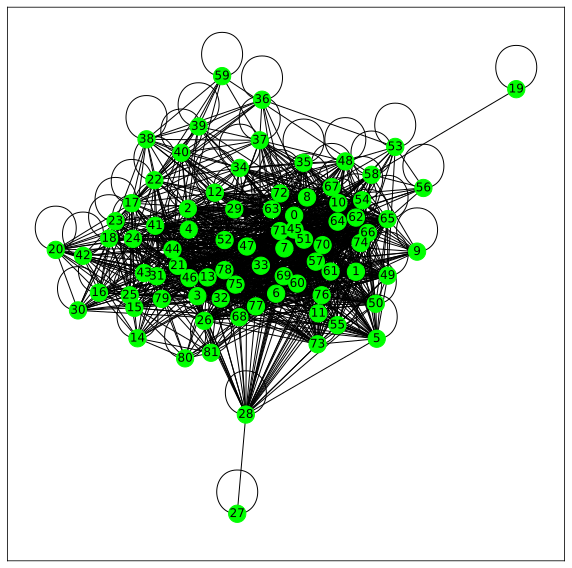

In [43]:
!pip install networkx


import networkx

similarity_graph = networkx.from_numpy_array(similitudes)

# A modo de visualización, representamos el grafo resultante
plt.figure(figsize=(10, 10))
networkx.draw_networkx(similarity_graph, node_color='lime')


**Usando "networkx.pagerank" podemos calcular los TR scores y encontrar las frases con mayor valor**:

In [44]:
num_sentences = 8  # Número de frases a seleccionar

scores = networkx.pagerank(similarity_graph)

scores_values = np.fromiter(scores.values(), dtype=float)

top_sentence_indices = np.argsort(-scores_values)[:num_sentences]

print("Estos son los índices de frase con mayor TR:")
for index in top_sentence_indices:
  print(index, scores_values[index])

# Ordenamos los índices según orden de aparición en el texto:
top_sentence_indices.sort()
print(top_sentence_indices)

print("\nEstas son las principales frases, según aparición en el texto:\n")
for l in top_sentence_indices:
    print(frases_list[l])
    print('-' * 100)


Estos son los índices de frase con mayor TR:
10 0.0176711342397622
29 0.01701760394275593
46 0.016886653068360406
63 0.016842728794778997
21 0.01628807769388838
45 0.016282033158110543
6 0.016264503348716687
52 0.016260532916650625
[ 6 10 21 29 45 46 52 63]

Estas son las principales frases, según aparición en el texto:

It became the fastest selling video game of 2006, the second-most played game over Xbox Live during 2007, and the 6th best selling Xbox 360 game.
----------------------------------------------------------------------------------------------------
Gears of War's success led to the development of a franchise, including four sequels (Gears of War 2 in 2008, Gears of War 3 in 2011, Gears of War 4 in 2016, and Gears 5 in 2019) and two prequels, Gears of War: Judgment, which was released in 2013 and Gears Tactics which was released in 2020.
----------------------------------------------------------------------------------------------------
The game features a five-act campai


### 4.4 Implementación usando `gensim` (**ya no disponible**).

Gensim proporcionaba una [función directa para TextRank](https://radimrehurek.com/gensim_3.8.3/summarization/summariser.html) que realiza internamente todo el preprocesado. Sin embargo **esta opción se ha eliminado en las últimas versiones de Gensim**, ya que no proporcionaba muy buenas prestaciones. la última versión de gensim que dispone de ese método es la 3.8.3.


# 5 - Determinación de palabras clave (keywords)

A continuación enumeramos **dos técnicas sencillas para determinar palabras clave en un documento: algoritmo RAKE y colocaciones**.



## 5.1 - Algoritmo RAKE

[Rapid Automatic Keyword Extraction](https://medium.datadriveninvestor.com/rake-rapid-automatic-keyword-extraction-algorithm-f4ec17b2886c) (RAKE) es un conocido **método de extracción de palabras clave** (keywords) que utiliza una lista de  delimitadores de frases para detectar las **secuencias de palabras** más relevantes en un fragmento de texto (**no necesariamente frases completas**). Por tanto el término **"keyword" se refiere a una secuencia de una o más palabras**.  Este método está muy bien descrito en este [capítulo de libro](https://catalogimages.wiley.com/images/db/pdf/9780470749821.excerpt.pdf). Se basa en la observación de que las "keywords" definidas manualmente **raras veces contienen signos de puntuación, stopwords u otras palabras con significado léxico menor**.

Texto de ejemplo (Título + Abstract), **los separadores usados por RAKE marcados en negrita**:

`Compatibility` **of** `systems` **of** `linear constraints` **over the** `set` **of** `natural numbers`**.**

`Criteria` **of** `compatibility` **of a** `system` **of** `linear Diophantine equations`**,** `strict inequations`**, and** `nonstrict inequations` **are considered.** `Upper bounds` **for** `components` **of a** `minimal set` **of** `solutions` **and** `algorithms` **of construction of** `minimal generating sets` **of** `solutions` **for all types of** `systems` **are given. These** `criteria` **and the** `corresponding algorithms` **for** `constructing` **a** `minimal supporting set` **of** `solutions` **can be used in** `solving` **all the considered types of** `systems` **and** `systems` **of mixed types.**



RAKE comienza la extracción de palabras clave en un documento extrayendo un **conjunto de palabras clave candidatas**. Primero, el documento se divide en una serie de palabras usando como delimitadores las palabras
anteriormante descritas (puntuación, stopwords, etc.).


*Compatibility – systems – linear constraints – set – natural numbers – Criteria – compatibility – system – linear Diophantine equations – strict inequations – nonstrict inequations – Upper bounds – components – minimal set – solutions – algorithms – minimal generating sets – solutions – systems – criteria – corresponding algorithms – constructing – minimal supporting set – solving – systems – systems*

A continuación es necesario calcular la matriz de co-ocurrencias de palabras, según diferentes medidas en el grafo de interconexión de palabras (más detalles en este [enlace](https://catalogimages.wiley.com/images/db/pdf/9780470749821.excerpt.pdf)):


<img src='http://www.tsc.uc3m.es/~navia/figures/RAKE_coocurrences.png' width=700 />



Por ejemplo, la palabra "algorithms" aparece en dos ocasiones, una de ellas aislada y la segunda en "corresponding algorithms". A partir de esta matriz se pueden realizar medidas sobre las palabras: la frecuancia es el número total de veces que aparece (valor de la diagonal), y el grado es el número de conexiones que salen o entran a ese nodo (suma de los valores de la fila/columna). Podemos por tanto definir varias medidas de valor de las palabras:

<img src='http://www.tsc.uc3m.es/~navia/figures/word_scores.PNG' width=700 />


A continuación, se define la puntuación de cada keyword como la suma de las puntuaciones de las palabras que la componen. El ranking resultante para la medida "grado / frecuencia" sería como sigue:

- minimal generating sets (8.7)
- linear diophantine equations (8.5)
- minimal supporting set (7.7)
- minimal set (4.7)
- linear constraints (4.5)
- natural numbers (4)
- strict inequations (4)
- nonstrict inequations (4)
- upper bounds (4)
- corresponding algorithms (3.5)
- set (2)
- algorithms (1.5)
- compatibility (1)
- systems (1)
- criteria (1)
- system (1)
- components (1)
- constructing (1)
- solving (1)


Como las keywords no contienen stop words u otras palabras de enlace, en algunas ocasiones (no en este ejemplo) es posible realizar un **procesado final para unir keywords**, cuando dos o más keywords aparecen con cierta frecuencia unidas entre sí por uno de dichos tipos de palabras.

Las keywords extraídas por RAKE para este ejemplo serían las siguientes. Es interesante **comparar los resultados de RAKE con respecto a las keywords definidas manualmente** por el autor del texto:

<img src='http://www.tsc.uc3m.es/~navia/figures/RAKE_comparison.png' width=500 />

En comparación a LSA o TextRank, **RAKE se caracteriza por una menor complejidad computacional**, que puede ser un aspecto crítico en documentos muy largos.

<img src='http://www.tsc.uc3m.es/~navia/figures/RAKE.png' width=400 />


Aunque **RAKE no está incluído en gensim, pero sí en** [**NLTK**](https://pypi.org/project/rake-nltk/).

In [45]:
nltk.download('punkt_tab')
nltk.download('stopwords')
from rake_nltk import Rake

RAKE = Rake()

# Example usage with DOCUMENT
RAKE.extract_keywords_from_text(document)

# Get the keywords
keywords = RAKE.get_ranked_phrases()

[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/matveypro/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/matveypro/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


In [46]:
# Print the main 10 keywords
for k in range(10):
  print(keywords[k])

interactive entertainment business jeff bell stated gears
epic games vice president mark rein posted
three million copies within ten weeks
6th best selling xbox 360 game
players must execute downed foes
war lead designer cliff bleszinski said
bleszinski also cited bionic commando
would ultimately cost microsoft tens
also aid delta squad throughout
highly valued power source


## 5.2 - Colocaciones (Collocations)

Una colocación se puede definir como una secuencia o grupo de palabras que tienden a ocurrir con frecuencia y esta frecuencia tiende a ser más de lo que podría denominarse una ocurrencia aleatoria o casual. Las colocaciones se calculan a partir de la codificación del texto mediante **n-grams** (secuencias de n palabras consecutivas) y la posterior determinación de los n-grams más frecuentes.

NLTK proporciona funciones para encontrar las colocaciones en el texto y establecer un ranking de acuerdo a diferentes métricas (frecuencia de aparición, información mútua o log-verosimilitud, entre otras).

Vamos a determinar las **colocaciones a partir de bi-gramas** más representativas en el texto de ejemplo:


In [47]:
from nltk.collocations import BigramCollocationFinder
from nltk.collocations import BigramAssocMeasures

# Usamos norm_sent_tokens, la versión de tokens normalizados, por frases
finder = BigramCollocationFinder.from_words([w for s in norm_sent_tokens for w in s]) # Pasamos el documento normalizado, sin dividir en frases

# Ranking: frecuencia del bi-grama
best_bigrams = finder.nbest(BigramAssocMeasures.raw_freq, 10)
print('-' * 50)
print("Mejores bigramas según la frecuencia:")
print('-' * 50)
for b in best_bigrams:
  print("{} {}".format(b[0], b[1]))
print('-' * 50)

# Ranking: likelihood_ratio
best_bigrams = finder.nbest(BigramAssocMeasures.likelihood_ratio, 10)
print("\n")
print('-' * 50)
print("Mejores bigramas según likelihood_ratio:")
print('-' * 50)
for b in best_bigrams:
  print("{} {}".format(b[0], b[1]))
print('-' * 50)


--------------------------------------------------
Mejores bigramas según la frecuencia:
--------------------------------------------------
gears war
xbox 360
epic games
gear war
delta squad
cliff bleszinski
e day
game receive
planet sera
player control
--------------------------------------------------


--------------------------------------------------
Mejores bigramas según likelihood_ratio:
--------------------------------------------------
gears war
xbox 360
epic games
gear war
delta squad
e day
planet sera
cliff bleszinski
casual hardcore
developers conference
--------------------------------------------------


Podemos proceder de forma similar con los **tri-gramas**:

In [48]:
from nltk.collocations import TrigramCollocationFinder
from nltk.collocations import TrigramAssocMeasures

# Usamos norm_sent_tokens, la versión de tokens normalizados, por frases
finder = TrigramCollocationFinder.from_words([w for s in norm_sent_tokens for w in s]) # Pasamos el documento normalizado, sin dividir en frases

# Ranking: frecuencia del bi-grama
best_trigrams = finder.nbest(TrigramAssocMeasures.raw_freq, 10)
print('-' * 50)
print("Mejores tri-gramas según la frecuencia:")
print('-' * 50)
for b in best_trigrams:
  print("{} {} {}".format(b[0], b[1], b[2]))
print('-' * 50)

# Ranking: likelihood_ratio
best_trigrams = finder.nbest(TrigramAssocMeasures.likelihood_ratio, 10)
print("\n")
print('-' * 50)
print("Mejores tri-gramas según likelihood_ratio:")
print('-' * 50)
for b in best_trigrams:
  print("{} {} {}".format(b[0], b[1], b[2]))
print('-' * 50)


--------------------------------------------------
Mejores tri-gramas según la frecuencia:
--------------------------------------------------
game developers conference
gears war game
receive universal acclaim
resident evil 4
sequel gears war
unreal engine 3
xbox 360 game
10 million accord
2 2008 gears
2 officially confirm
--------------------------------------------------


--------------------------------------------------
Mejores tri-gramas según likelihood_ratio:
--------------------------------------------------
sequel gears war
gears war 2
version gears war
ending gears war
gears war halo
gears war heavily
gears war internet
gears war judgment
gears war offer
gears war original
--------------------------------------------------


De forma análoga podemos obtener los **cuadri-gramas**:

In [49]:
from nltk.collocations import QuadgramCollocationFinder
from nltk.collocations import QuadgramAssocMeasures

# Usamos norm_sent_tokens, la versión de tokens normalizados, por frases
finder = QuadgramCollocationFinder.from_words([w for s in norm_sent_tokens for w in s]) # Pasamos el documento normalizado, sin dividir en frases

# Ranking: frecuencia del bi-grama
best_quadgrams = finder.nbest(QuadgramAssocMeasures.raw_freq, 10)
print('-' * 50)
print("Mejores cuadri-gramas según la frecuencia:")
print('-' * 50)
for b in best_quadgrams:
  print("{} {} {} {}".format(b[0], b[1], b[2], b[3]))
print('-' * 50)

# Ranking: likelihood_ratio
best_quadgrams = finder.nbest(QuadgramAssocMeasures.likelihood_ratio, 10)
print("\n")
print('-' * 50)
print("Mejores cuadri-gramas según likelihood_ratio:")
print('-' * 50)
for b in best_quadgrams:
  print("{} {} {} {}".format(b[0], b[1], b[2], b[3]))
print('-' * 50)


--------------------------------------------------
Mejores cuadri-gramas según la frecuencia:
--------------------------------------------------
10 million accord epic
2 2008 gears war
2 officially confirm february
20 2008 release midnight
20 30 people involve
2000 2001 unreal warfare
2001 unreal warfare close
2005 game developers conference
2006 microsoft corporate vp
2006 microsoft windows version
--------------------------------------------------


--------------------------------------------------
Mejores cuadri-gramas según likelihood_ratio:
--------------------------------------------------
gears war xbox 360
sequel gears war 2
gears war ultimate edition
gears war 2 officially
gears war receive universal
intend sequel gears war
game sequel gears war
lead designer gears war
remastered version gears war
2019 prequel gears war
--------------------------------------------------


Podemos observar como los n-grams obtenidos en el ranking dan información relevante acerca del contenido del documento. De hecho, la caracterización de un texto mediante el conteo completo de sus n-grams da lugar a una representación vectorial conocida como **Bag-of-n-grams**, una extensión natural de **Bag-of-words**.

### Ejercicio de ampliación (opcional):

- Utilizando el corpus de discursos de presidentes USA, realice un análisis y extraiga la frase más significativa del discurso de cada presidente.

- Extraiga también las principales "keywords" de cada discurso.

**Nota:** puede utilizar cualquiera de las técnicas vistas en este tema.  